# Generated vs. Corpus — how different are the sampled songs?

The generator samples from distributions measured on the corpus, so we expect two
things to both be true:

- **Distributionally faithful** — generated songs should use functions, sounds,
  lengths and note-transitions in *roughly the same proportions* as the corpus
  (that's the point of sampling from it).
- **Instance-novel** — the actual songs/strings should be *new*, not copies.

This notebook checks both, comparing `dataset/generated_500.json` to
`corpus/sources/`.

## 1. Load corpus + generated, parse both the same way

In [1]:
%matplotlib inline
import os, re, json, math, collections
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})
C_COL, G_COL = "#4C72B0", "#C44E52"   # corpus / generated

root = Path.cwd()
for _ in range(6):
    if (root / "dataset" / "generated_500.json").exists(): break
    root = root.parent
GEN = json.load(open(root / "dataset" / "generated_500.json"))
print("generated:", GEN["count"], "songs |", GEN["params"])

# --- corpus snippet extraction (same as 01) ---
EXTS=(".js",".mjs",".mdx",".md",".txt")
PLAY=re.compile(r"(\$:|setcps?\(|setcpm\(|\bstack\s*\(|\bnote\s*\(|\bsound\s*\(|\.s\s*\(|\bs\s*\(\s*[\"'`])")
SKIP=re.compile(r"(node_modules|/dist/|/build/|\.test\.|/krill|/parser|packages/.*/src/)",re.I)
def extract(path,text):
    e=os.path.splitext(path)[1].lower(); f=[]
    if e in(".mjs",".js"): f+=re.findall(r"=\s*`(.*?)`",text,re.S)
    if e in(".mdx",".md"): f+=re.findall(r"```[a-zA-Z]*\n(.*?)```",text,re.S)
    if not f and e in(".js",".mjs",".txt"): f.append(text)
    return [s for s in f if PLAY.search(s) and 15<len(s)<20000]
CORPUS = root/"corpus"/"sources"; snippets=[]; seen=set()
for dp,_,fs in os.walk(CORPUS):
    if "/.git" in dp: continue
    for fn in fs:
        if not fn.endswith(EXTS): continue
        p=os.path.join(dp,fn); rel=os.path.relpath(p,CORPUS)
        if SKIP.search("/"+rel): continue
        try: t=open(p,encoding="utf-8",errors="ignore").read()
        except Exception: continue
        for sn in extract(p,t):
            h=re.sub(r"\s+","",sn)
            if h in seen: continue
            seen.add(h); snippets.append(sn)
print("corpus:", len(snippets), "snippets")

generated: 500 songs | {'n': 500, 'seed': 1, 'temp': 0.2, 'max_order': 6}


corpus: 855 snippets


In [2]:
# parse any code string into: function calls, sound tokens, per-fn token sequences
def call_args(code):
    i,N=0,len(code)
    while i<N:
        m=re.match(r"[A-Za-z_]\w*",code[i:])
        if m and (i==0 or not(code[i-1].isalnum() or code[i-1]=='_')):
            j=i+m.end();k=j
            while k<N and code[k] in " \t\n":k+=1
            if k<N and code[k]=='(':
                d,p,ins=1,k+1,None
                while p<N and d:
                    c=code[p]
                    if ins:
                        if c=='\\':p+=1
                        elif c==ins:ins=None
                    elif c in '"\'`':ins=c
                    elif c=='(':d+=1
                    elif c==')':d-=1
                    p+=1
                yield m.group(0),code[k+1:p-1].strip();i=k+1;continue
            i=j;continue
        i+=1
STR=re.compile(r"""^["'`](.*)["'`]$""",re.S)
ATOM=re.compile(r"~|[A-Za-z][\w#.]*(?:[:*!@][0-9.]+)*|-?\d+(?:\.\d+)?(?:[:*!@][0-9.]+)*")
def leaf_tokens(s):
    s=re.sub(r"\([0-9,.\s]*\)","",s); s=re.sub(r"([)\]}>])\s*[*!/@][0-9.]+",r"\1",s)
    return ATOM.findall(s)
JS_NOISE={"function","register","if","for","while","return","const","let","var","map",
    "filter","forEach","withValue","console","log","Math","require","import","export"}

def parse(code):
    calls=[]; sounds=[]; seqs=collections.defaultdict(list)
    for fn,arg in call_args(code):
        if fn in JS_NOISE: continue
        calls.append(fn)
        m=STR.match(arg)
        if m and fn in ("note","n","s","sound"):
            ts=leaf_tokens(m.group(1))
            if ts: seqs[fn].append(ts)
        if m and fn in ("s","sound"):
            for tok in leaf_tokens(m.group(1)):
                if tok!="~": sounds.append(tok.split(":")[0].split("*")[0].split("@")[0])
    return calls, sounds, seqs

def aggregate(codes):
    fns=collections.Counter(); snd=collections.Counter(); seqs=collections.defaultdict(list)
    tokensets=[]
    for c in codes:
        ca,so,sq=parse(c); fns.update(ca); snd.update(so)
        for k,v in sq.items(): seqs[k]+=v
        ts=set(ca)|set(so)
        for v in sq.values():
            for seq in v: ts|=set(seq)
        tokensets.append(ts)
    return fns, snd, seqs, tokensets

corpus_fns, corpus_snd, corpus_seqs, corpus_sets = aggregate(snippets)
def song_code(s):
    c = s["code"]
    return "\n".join(c) if isinstance(c, list) else c
gen_codes=[song_code(s) for s in GEN["songs"]]
gen_fns, gen_snd, gen_seqs, gen_sets = aggregate(gen_codes)
print("corpus functions:", len(corpus_fns), "| generated functions:", len(gen_fns))

corpus functions: 833 | generated functions: 41


## 2. Similarity metrics

In [3]:
def to_prob(counter):
    tot=sum(counter.values()) or 1
    return {k:v/tot for k,v in counter.items()}
def cosine(a,b):
    keys=set(a)|set(b)
    dot=sum(a.get(k,0)*b.get(k,0) for k in keys)
    na=math.sqrt(sum(v*v for v in a.values())); nb=math.sqrt(sum(v*v for v in b.values()))
    return dot/(na*nb) if na and nb else 0.0
def js_div(a,b):
    keys=set(a)|set(b); pa=to_prob(a); pb=to_prob(b)
    m={k:(pa.get(k,0)+pb.get(k,0))/2 for k in keys}
    kl=lambda p:sum(p.get(k,0)*math.log2(p[k]/m[k]) for k in keys if p.get(k,0)>0)
    return round((kl(pa)+kl(pb))/2,3)   # 0=identical … 1=disjoint (bits)

print("FUNCTION usage  cosine=%.3f  JS-divergence=%.3f" % (
    cosine(to_prob(corpus_fns),to_prob(gen_fns)), js_div(corpus_fns,gen_fns)))
print("SOUND usage     cosine=%.3f  JS-divergence=%.3f" % (
    cosine(to_prob(corpus_snd),to_prob(gen_snd)), js_div(corpus_snd,gen_snd)))

FUNCTION usage  cosine=0.910  JS-divergence=0.301
SOUND usage     cosine=0.847  JS-divergence=0.150


## 3. Function usage — corpus vs generated

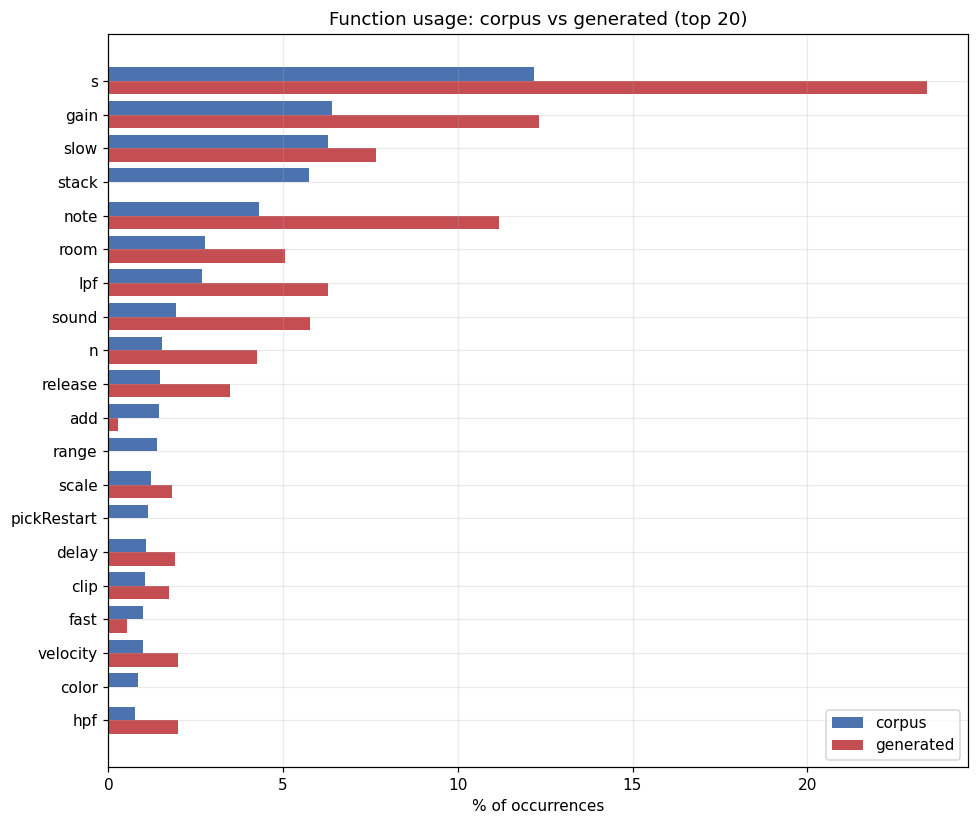

In [4]:
def side_by_side(cc, gc, title, n=20):
    top=[k for k,_ in cc.most_common(n)]
    cp=to_prob(cc); gp=to_prob(gc)
    y=np.arange(len(top))[::-1]
    fig,ax=plt.subplots(figsize=(9,max(4,.38*len(top))))
    ax.barh(y+0.2,[cp.get(k,0)*100 for k in top],height=.4,color=C_COL,label="corpus")
    ax.barh(y-0.2,[gp.get(k,0)*100 for k in top],height=.4,color=G_COL,label="generated")
    ax.set_yticks(y); ax.set_yticklabels(top); ax.set_xlabel("% of occurrences")
    ax.set_title(title); ax.legend(); plt.tight_layout(); plt.show()
side_by_side(corpus_fns,gen_fns,"Function usage: corpus vs generated (top 20)")

## 4. Sound usage — corpus vs generated

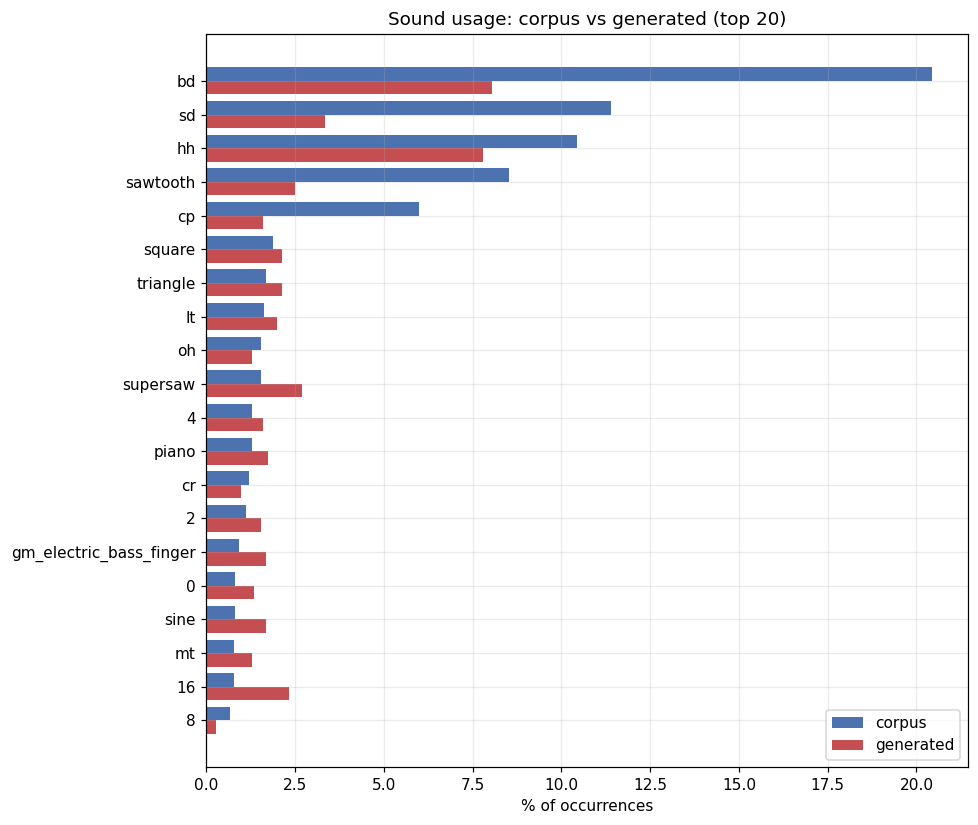

In [5]:
side_by_side(corpus_snd,gen_snd,"Sound usage: corpus vs generated (top 20)")

## 5. Structure — voices per song & sequence lengths

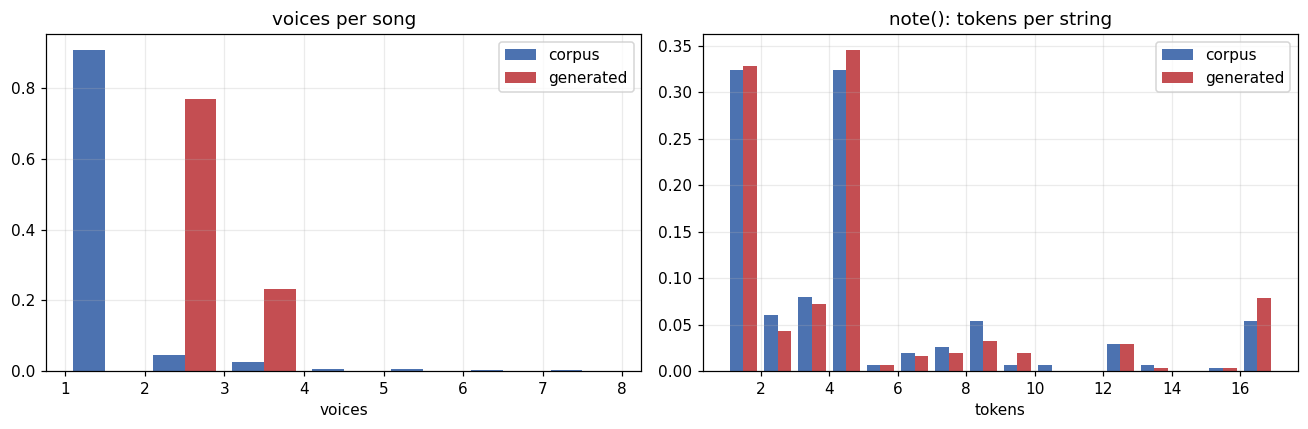

In [6]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
corpus_voices=[max(1,c.count("$:")+c.count("stack(")) for c in snippets]
gen_voices=[s["voices"] for s in GEN["songs"]]
bins=np.arange(1,9)
ax[0].hist([corpus_voices,gen_voices],bins=bins,color=[C_COL,G_COL],
           label=["corpus","generated"],density=True)
ax[0].set_title("voices per song"); ax[0].set_xlabel("voices"); ax[0].legend()
cl=[len(s) for s in corpus_seqs["note"]]; gl=[len(s) for s in gen_seqs["note"]]
ax[1].hist([cl,gl],bins=np.arange(1,18),color=[C_COL,G_COL],
           label=["corpus","generated"],density=True)
ax[1].set_title("note(): tokens per string"); ax[1].set_xlabel("tokens"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Note→note transitions — does the generator reproduce them?

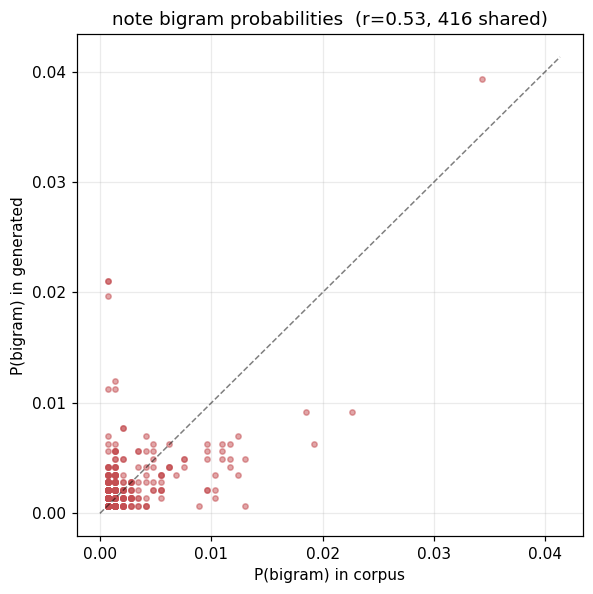

In [7]:
def bigrams(seqs):
    b=collections.Counter()
    for s in seqs:
        for a,c in zip(s,s[1:]): b[(a,c)]+=1
    return b
cb=bigrams(corpus_seqs["note"]); gb=bigrams(gen_seqs["note"])
shared=[k for k in cb if k in gb]
cp=to_prob(cb); gp=to_prob(gb)
xs=[cp[k] for k in shared]; ys=[gp[k] for k in shared]
r=np.corrcoef(xs,ys)[0,1] if len(shared)>2 else float("nan")
plt.figure(figsize=(5.5,5.5))
plt.scatter(xs,ys,s=12,alpha=.5,color=G_COL)
lim=max(max(xs,default=0),max(ys,default=0))*1.05
plt.plot([0,lim],[0,lim],"k--",lw=1,alpha=.5)
plt.xlabel("P(bigram) in corpus"); plt.ylabel("P(bigram) in generated")
plt.title(f"note bigram probabilities  (r={r:.2f}, {len(shared)} shared)")
plt.tight_layout(); plt.show()

## 7. Novelty — how *different* are the actual songs?

Faithful distributions are only good if the songs themselves are new. Three checks:
verbatim string reuse, verbatim song reuse, and nearest-neighbour similarity.

sequence strings: 1333, novel (not verbatim in corpus): 51.5%
whole songs: 500, novel: 100.0%  | unique generated: 500


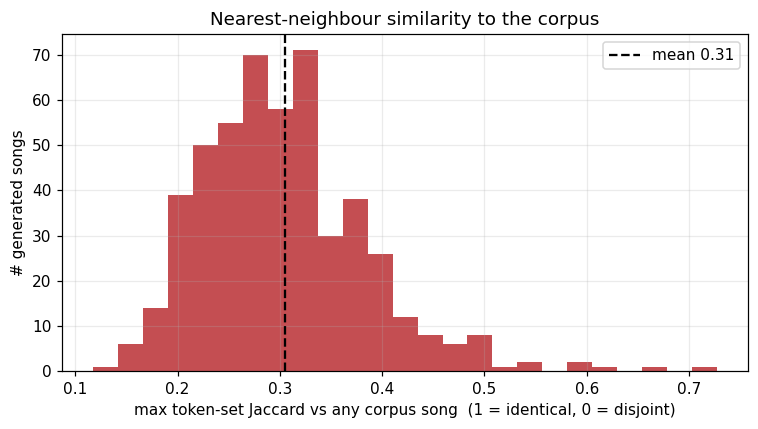

nearest-neighbour Jaccard: mean 0.31, max 0.73


In [8]:
# verbatim sequence-string reuse
def str_set(seqs_by_fn):
    return {(fn," ".join(s)) for fn,v in seqs_by_fn.items() for s in v}
corpus_strs=str_set(corpus_seqs); gen_str_list=[(fn," ".join(s)) for fn,v in gen_seqs.items() for s in v]
novel_str=sum(1 for x in gen_str_list if x not in corpus_strs)
print("sequence strings: %d, novel (not verbatim in corpus): %.1f%%" %
      (len(gen_str_list), 100*novel_str/len(gen_str_list)))

# verbatim whole-song reuse
corpus_norm={re.sub(r"\s+","",s) for s in snippets}
novel_song=sum(1 for c in gen_codes if re.sub(r"\s+","",c) not in corpus_norm)
print("whole songs: %d, novel: %.1f%%  | unique generated: %d" %
      (len(gen_codes), 100*novel_song/len(gen_codes), len({c for c in gen_codes})))

# nearest-neighbour Jaccard (each generated song vs its closest corpus snippet)
def jacc(a,b):
    u=len(a|b); return len(a&b)/u if u else 0
nn=[max((jacc(g,c) for c in corpus_sets), default=0) for g in gen_sets]
plt.figure(figsize=(7,4))
plt.hist(nn,bins=25,color=G_COL)
plt.axvline(np.mean(nn),color="k",ls="--",label=f"mean {np.mean(nn):.2f}")
plt.xlabel("max token-set Jaccard vs any corpus song  (1 = identical, 0 = disjoint)")
plt.ylabel("# generated songs"); plt.title("Nearest-neighbour similarity to the corpus")
plt.legend(); plt.tight_layout(); plt.show()
print("nearest-neighbour Jaccard: mean %.2f, max %.2f" % (np.mean(nn), np.max(nn)))

## Summary

- **Distributional fidelity:** function- and sound-usage cosine/JS-divergence and
  the bigram scatter show how closely the generated set tracks the corpus it was
  sampled from.
- **Instance novelty:** most sequence strings and (essentially) all whole songs
  are new, and nearest-neighbour Jaccard shows generated songs share only a
  fraction of their tokens with the closest corpus song.

Together: the generator reproduces the corpus *statistics* while producing *new*
songs — which is exactly what we want for training data.